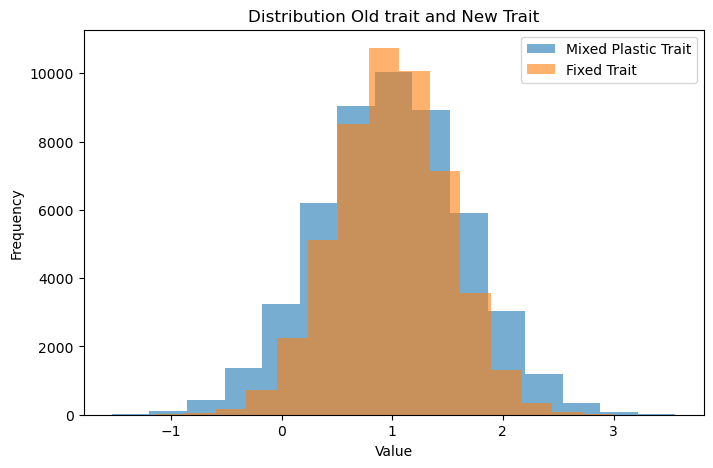

In [60]:
import numpy as np
import matplotlib.pyplot as plt


np.random.seed(4)

coef_stability=0.5
t=2 #temperature
initial_trait= np.random.normal(loc=1, scale=0.5, size=50000)
#I loop for 3 years because trait can change up to three times on a life of a mouse
for i in range(3):
    update_trait = np.random.normal(loc=0, scale=0.5, size=50000)
    new_trait = initial_trait  + update_trait * coef_stability
    initial_trait= new_trait
    
fixed_trait= np.random.normal(loc=1, scale=0.5, size=50000) #
mixed_trait= initial_trait


plt.figure(figsize=(8, 5))

plt.hist(mixed_trait, bins=15, alpha=0.6, label='Mixed Plastic Trait')
plt.hist(fixed_trait, bins=15, alpha=0.6, label='Fixed Trait')

plt.xlabel('Value')
plt.ylabel('Frequency')
plt.title('Distribution Old trait and New Trait')
plt.legend()
plt.show()

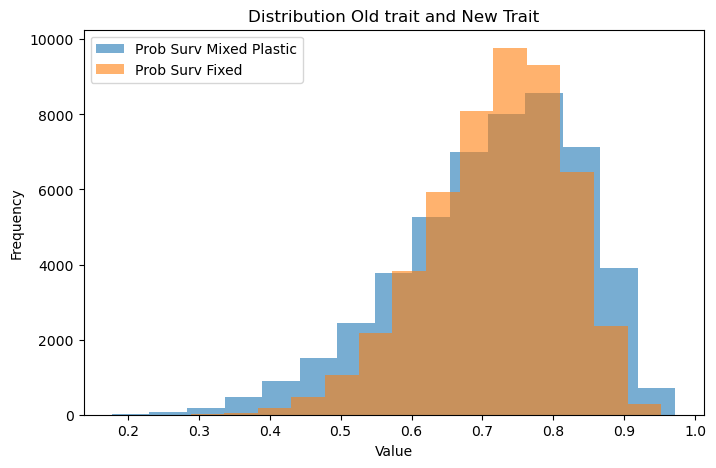

In [62]:
from scipy.stats import logistic
p_surv_fix= logistic.cdf(fixed_trait, loc=0, scale=1)
p_surv_mix= logistic.cdf(mixed_trait, loc=0, scale=1)

plt.figure(figsize=(8, 5))

plt.hist(p_surv_mix, bins=15, alpha=0.6, label='Prob Surv Mixed Plastic')
plt.hist(p_surv_fix, bins=15, alpha=0.6, label='Prob Surv Fixed')

plt.xlabel('Value')
plt.ylabel('Frequency')
plt.title('Distribution Old trait and New Trait')
plt.legend()
plt.show()

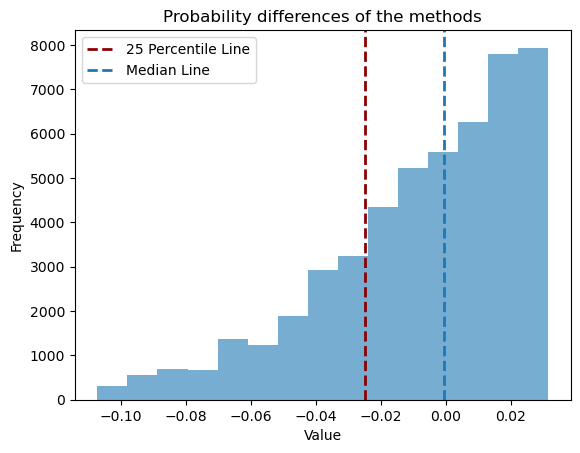

In [66]:
diff =  np.array(sorted(p_surv_mix)) - np.array(sorted(p_surv_fix))

plt.hist(diff, bins=15, alpha=0.6)
median = np.percentile(diff, 50)
perc_25 = np.percentile(diff, 25)
plt.axvline(perc_25, linestyle='--', linewidth=2, color= "darkred", label=f'25 Percentile Line')
plt.axvline(median, linestyle='--', linewidth=2, label=f'Median Line')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.title('Probability differences of the methods')
plt.legend()
plt.show()

## Quick interpretation:
The fact that the median is 0 indicates that, overall, there is **no net change** in survival probability between the Mixed Scenario and the Fixed Scenario.
However, the distribution of differences is **skewed**: for roughly half of the individuals, the new scenario produces lower survival probabilities, and a small subset experiences a strong negative effect. Because the difference distribution is right-skewed, the other half of the individuals show modest positive gains in survival.
Overall, this trade-off may still be beneficial for population stability: a small number of individuals are more likely to be removed, while the remaining half gains a consistent increase in survival probability.